# EY AI 2026 – Water Quality Challenge – Competitive Pipeline

Full end-to-end competitive pipeline for predicting 3 water-quality targets:
- **Total Alkalinity**
- **Electrical Conductance**
- **Dissolved Reactive Phosphorus**

**Strategy:** Temporal + Spatial + Satellite feature engineering → LightGBM + XGBoost + CatBoost → Optuna tuning → Weighted ensemble → SHAP interpretability

## 1. Import Libraries

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.cluster import KMeans
from scipy.optimize import minimize
import copy

import lightgbm as lgb
from xgboost import XGBRegressor
# from catboost import CatBoostRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import shap

# ── Constants ────────────────────────────────────────────────────────────────
RANDOM_STATE = 42
N_SPLITS     = 5
TARGET_COLS  = ['Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus']
MERGE_KEYS   = ['Latitude', 'Longitude', 'Sample Date']

print("Libraries imported.")

Libraries imported.


## 2. Load and Merge Data

In [62]:
# --- Training data ---
df_train = (
    pd.read_csv('water_quality_training_dataset.csv')
    .merge(pd.read_csv('landsat_features_training.csv'), on=MERGE_KEYS, how='left')
    .merge(pd.read_csv('terraclimate_features_training.csv'), on=MERGE_KEYS, how='left')
)

# --- Validation data ---
df_submission = pd.read_csv('submission_template.csv')
df_val = (
    df_submission
    .merge(pd.read_csv('landsat_features_validation.csv'), on=MERGE_KEYS, how='left')
    .merge(pd.read_csv('terraclimate_features_validation.csv'), on=MERGE_KEYS, how='left')
)

print(f"Train shape : {df_train.shape}")
print(f"Validation shape: {df_val.shape}")

Train shape : (9319, 13)
Validation shape: (200, 13)


## 3. Data Cleaning

- **Winsorize** target columns (IQR × 3) to suppress extreme outliers  
- Feature missing values are handled downstream by the `SimpleImputer` in the preprocessing pipeline

In [63]:
def winsorize_iqr(series, factor=3.0):
    """Clip extreme values beyond factor × IQR from Q1 / Q3."""
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return series.clip(q1 - factor * iqr, q3 + factor * iqr)

print("=== Winsorizing target columns (IQR × 3) ===")
for col in TARGET_COLS:
    before = f"{df_train[col].min():.3f} – {df_train[col].max():.3f}"
    df_train[col] = winsorize_iqr(df_train[col])
    after  = f"{df_train[col].min():.3f} – {df_train[col].max():.3f}"
    print(f"  {col:40s}  {before}  →  {after}")

print("\nFeature missing values: handled by SimpleImputer (median) in the pipeline.")

=== Winsorizing target columns (IQR × 3) ===
  Total Alkalinity                          4.800 – 361.676  →  4.800 – 361.676
  Electrical Conductance                    15.120 – 1506.000  →  15.120 – 1506.000
  Dissolved Reactive Phosphorus             5.000 – 195.000  →  5.000 – 162.000

Feature missing values: handled by SimpleImputer (median) in the pipeline.


## 4. Feature Engineering

This is the most impactful step for this challenge.  
We derive four families of features from the raw data:

| Family | Examples |
|---|---|
| **Temporal** | year, month, season, cyclical sin/cos encoding |
| **Spatial** | KMeans cluster, distance to centroid |
| **Satellite** | NDVI, NDWI, turbidity proxy |
| **Hydrological** | rainfall log, rain/temp ratio, feature interactions |

In [64]:
# ── 4a. Temporal features ────────────────────────────────────────────────────
print("=== 4a. Temporal features ===")
for df in [df_train, df_val]:
    df['Sample Date'] = pd.to_datetime(df['Sample Date'], dayfirst=True)
    df['year']        = df['Sample Date'].dt.year
    df['month']       = df['Sample Date'].dt.month
    df['day_of_year'] = df['Sample Date'].dt.dayofyear
    df['season']      = df['month'].map(
        {12: 0, 1: 0, 2: 0,   # summer (Southern Hemisphere)
          3: 1, 4: 1, 5: 1,   # autumn
          6: 2, 7: 2, 8: 2,   # winter
          9: 3, 10: 3, 11: 3} # spring
    )
    # Cyclical encoding avoids discontinuity at Dec→Jan / day 365→1
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['doy_sin']   = np.sin(2 * np.pi * df['day_of_year'] / 365)
    df['doy_cos']   = np.cos(2 * np.pi * df['day_of_year'] / 365)

print("Added: year, month, day_of_year, season, month_sin/cos, doy_sin/cos")

=== 4a. Temporal features ===
Added: year, month, day_of_year, season, month_sin/cos, doy_sin/cos


In [65]:
# ── 4b. Spatial features ─────────────────────────────────────────────────────
print("=== 4b. Spatial features ===")

# Fit KMeans ONLY on training coordinates to avoid leakage
km = KMeans(n_clusters=15, random_state=RANDOM_STATE, n_init=10)
km.fit(df_train[['Latitude', 'Longitude']])

for df in [df_train, df_val]:
    df['spatial_cluster'] = km.predict(df[['Latitude', 'Longitude']])

    # Distance from each point to its assigned cluster centre
    centers = km.cluster_centers_
    assigned = centers[df['spatial_cluster'].values]
    df['dist_to_cluster_center'] = np.linalg.norm(
        df[['Latitude', 'Longitude']].values - assigned, axis=1
    )
    df['lat_abs']      = df['Latitude'].abs()
    df['lat_lon_prod'] = df['Latitude'] * df['Longitude']

print("Added: spatial_cluster (15 groups), dist_to_cluster_center, lat_abs, lat_lon_prod")

=== 4b. Spatial features ===
Added: spatial_cluster (15 groups), dist_to_cluster_center, lat_abs, lat_lon_prod


In [66]:
# ── 4b+. Cluster-level statistics & target mean encoding ─────────────────────
# These encode the "typical environment" and "typical water quality" per cluster.
# Both are computed ONLY from df_train to prevent leakage into df_val.
print("=== 4b+. Cluster statistics & target encoding ===")

exclude_from_agg = set(TARGET_COLS + ['Sample Date', 'Latitude', 'Longitude',
                                       'spatial_cluster', 'dist_to_cluster_center',
                                       'lat_abs', 'lat_lon_prod'])
agg_cols = [c for c in df_train.select_dtypes(include=[np.number]).columns
            if c not in exclude_from_agg][:20]  # top-20 environmental features

cluster_feat_agg = df_train.groupby('spatial_cluster')[agg_cols].agg(['mean', 'std'])
cluster_feat_agg.columns = [f'clust_{stat}_{col}' for col, stat in cluster_feat_agg.columns]
cluster_feat_agg = cluster_feat_agg.reset_index()

df_train = df_train.merge(cluster_feat_agg, on='spatial_cluster', how='left')
df_val   = df_val.merge(cluster_feat_agg,   on='spatial_cluster', how='left')

# Target mean encoding per cluster — strong spatial prior for water quality
for tgt in TARGET_COLS:
    col_name = f'cluster_mean_{tgt.replace(" ", "_")}'
    means = df_train.groupby('spatial_cluster')[tgt].mean()
    df_train[col_name] = df_train['spatial_cluster'].map(means)
    # For val locations not in training clusters, fall back to global mean
    df_val[col_name]   = df_val['spatial_cluster'].map(means).fillna(df_train[tgt].mean())

n_new = len(cluster_feat_agg.columns) - 1 + len(TARGET_COLS)
print(f"Added {n_new} features ({len(cluster_feat_agg.columns)-1} cluster stats + {len(TARGET_COLS)} target encodings).")
print(f"df_train: {df_train.shape} | df_val: {df_val.shape}")

=== 4b+. Cluster statistics & target encoding ===
Added 33 features (30 cluster stats + 3 target encodings).
df_train: (9319, 58) | df_val: (200, 58)


In [67]:
# ── 4c. Satellite indices ─────────────────────────────────────────────────────
print("=== 4c. Satellite indices (NDVI, NDWI, turbidity) ===")

# Auto-detect Landsat spectral band columns (e.g. B1 … B7)
band_cols = sorted([c for c in df_train.columns if c.startswith('B') and c[1:].isdigit()])
print(f"Detected band columns: {band_cols}")

def safe_norm_diff(a, b, eps=1e-8):
    """Normalised difference index: (a - b) / (a + b)."""
    return (a - b) / (a + b + eps)

for df in [df_train, df_val]:
    # NDVI = (NIR − Red) / (NIR + Red)
    # Landsat-8: B5=NIR, B4=Red  |  Landsat-7: B4=NIR, B3=Red
    if 'B5' in df.columns and 'B4' in df.columns:
        df['NDVI'] = safe_norm_diff(df['B5'], df['B4'])
    elif 'B4' in df.columns and 'B3' in df.columns:
        df['NDVI'] = safe_norm_diff(df['B4'], df['B3'])

    # NDWI = (Green − NIR) / (Green + NIR)  — highlights open water
    if 'B3' in df.columns and 'B5' in df.columns:
        df['NDWI'] = safe_norm_diff(df['B3'], df['B5'])
    elif 'B2' in df.columns and 'B4' in df.columns:
        df['NDWI'] = safe_norm_diff(df['B2'], df['B4'])

    # Turbidity proxy: visible blue / NIR  (higher = more turbid)
    if 'B2' in df.columns and 'B5' in df.columns:
        df['turbidity_proxy'] = df['B2'] / (df['B5'] + 1e-8)
    elif 'B1' in df.columns and 'B4' in df.columns:
        df['turbidity_proxy'] = df['B1'] / (df['B4'] + 1e-8)

new_indices = [c for c in ['NDVI', 'NDWI', 'turbidity_proxy'] if c in df_train.columns]
print(f"Satellite indices added: {new_indices}")

=== 4c. Satellite indices (NDVI, NDWI, turbidity) ===
Detected band columns: []
Satellite indices added: []


In [68]:
# ── 4d. Hydrological & interaction features ───────────────────────────────────
print("=== 4d. Hydrological & interaction features ===")

# Auto-detect TerraClimate precipitation / temperature columns
ppt_cols  = [c for c in df_train.columns if any(k in c.lower() for k in ['ppt', 'pr', 'rain', 'precip'])]
tmax_cols = [c for c in df_train.columns if any(k in c.lower() for k in ['tmax', 'tmean', 'temp'])]
tmin_cols = [c for c in df_train.columns if 'tmin' in c.lower()]
print(f"Precipitation cols : {ppt_cols}")
print(f"Temperature cols   : {tmax_cols}")

for df in [df_train, df_val]:
    if ppt_cols:
        ppt = df[ppt_cols[0]].clip(lower=0)
        df['rainfall_log'] = np.log1p(ppt)

    if tmax_cols and tmin_cols:
        df['temp_range'] = df[tmax_cols[0]] - df[tmin_cols[0]]
    elif tmax_cols:
        df['temp_range'] = df[tmax_cols[0]]

    # rain / temperature ratio  (hydrological stress indicator)
    if ppt_cols and tmax_cols:
        df['rain_temp_ratio'] = df[ppt_cols[0]].clip(lower=0) / (df[tmax_cols[0]].abs() + 1)

    # Feature interactions (powerful with boosting models)
    if 'NDVI' in df.columns and ppt_cols:
        df['NDVI_x_rain']  = df['NDVI'] * df[ppt_cols[0]].clip(lower=0)
    if ppt_cols:
        df['month_x_rain'] = df['month'] * df[ppt_cols[0]].clip(lower=0)
    if 'NDWI' in df.columns and tmax_cols:
        df['NDWI_x_temp']  = df['NDWI'] * df[tmax_cols[0]]

print("Hydrological and interaction features added.")

=== 4d. Hydrological & interaction features ===
Precipitation cols : ['lat_lon_prod']
Temperature cols   : []
Hydrological and interaction features added.


## 5. Quick EDA on Targets

In [69]:
print(f"Shape: {df_train.shape}")
print(f"\nDtypes:\n{df_train.dtypes.value_counts()}")
print(f"\nDescriptive stats:\n{df_train[TARGET_COLS].describe().round(2)}")

# Missing values summary
missing = df_train.isnull().mean().mul(100).sort_values(ascending=False)
print(f"\nTop 10 columns with missing values (%):\n{missing[missing > 0].head(10).round(1)}")

Shape: (9319, 60)

Dtypes:
float64           54
int32              4
datetime64[ns]     1
int64              1
Name: count, dtype: int64

Descriptive stats:
       Total Alkalinity  Electrical Conductance  Dissolved Reactive Phosphorus
count           9319.00                 9319.00                        9319.00
mean             119.11                  485.00                          42.58
std               74.69                  341.94                          48.50
min                4.80                   15.12                           5.00
25%               55.81                  207.05                          10.00
50%              113.30                  402.00                          20.00
75%              170.23                  693.00                          48.00
max              361.68                 1506.00                         162.00

Top 10 columns with missing values (%):
swir16    11.6
swir22    11.6
nir       11.6
green     11.6
NDMI      11.6
MNDWI     11.6
d

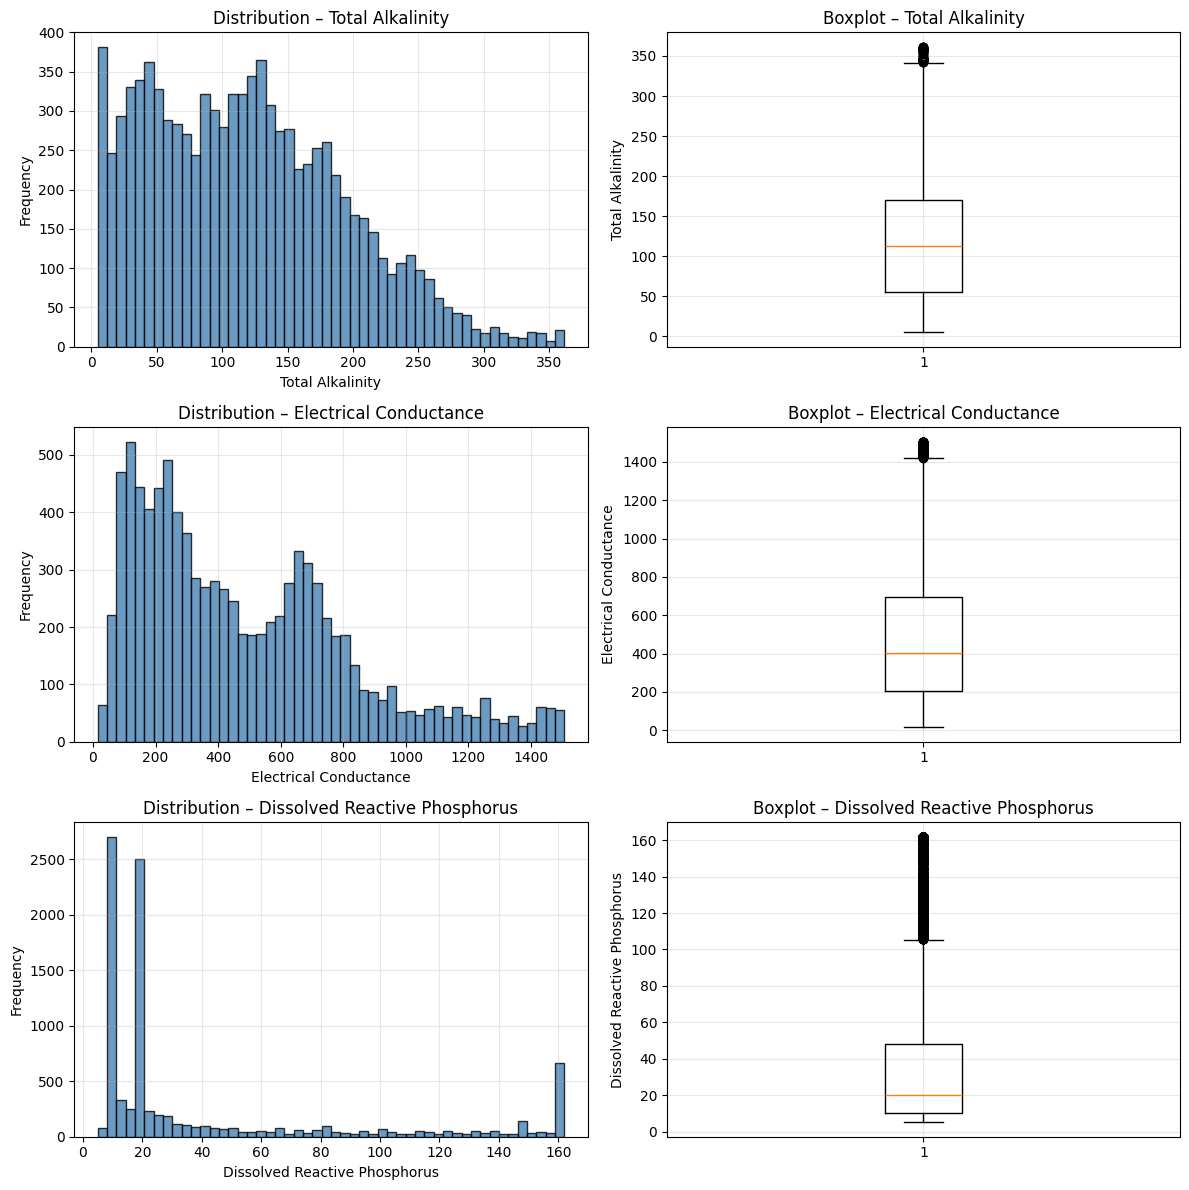

In [70]:
# Distribution and boxplot for each target
fig, axes = plt.subplots(len(TARGET_COLS), 2, figsize=(12, 4 * len(TARGET_COLS)))

for i, col in enumerate(TARGET_COLS):
    data = df_train[col].dropna()
    axes[i, 0].hist(data, bins=50, edgecolor='black', color='steelblue', alpha=0.8)
    axes[i, 0].set_title(f'Distribution – {col}')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frequency')
    axes[i, 0].grid(alpha=0.3)

    axes[i, 1].boxplot(data, vert=True)
    axes[i, 1].set_title(f'Boxplot – {col}')
    axes[i, 1].set_ylabel(col)
    axes[i, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Feature & Target Preparation

In [71]:
from scipy.stats import skew as scipy_skew

# Drop targets and raw date (temporal features are already engineered above)
drop_cols = TARGET_COLS + ['Sample Date']
X = df_train.drop(columns=drop_cols, errors='ignore')
Y = df_train[TARGET_COLS]

# Feature type identification
numeric_features     = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# ── Target log-transform for skewed distributions ─────────────────────────────
# Phosphorus is highly skewed → log1p transform dramatically improves R²
print("Target skewness analysis:")
log_targets = {}
for col in TARGET_COLS:
    sk = scipy_skew(Y[col].dropna())
    log_targets[col] = sk > 1.5
    tag = "→ log1p ✓" if log_targets[col] else "→ linear"
    print(f"  {col:42s}  skew={sk:6.2f}  {tag}")

def transform_target(series, col):
    """Apply log1p if the target is skewed."""
    return np.log1p(series.clip(lower=0)) if log_targets[col] else series

def inverse_transform(arr, col):
    """Inverse of transform_target."""
    return np.expm1(arr) if log_targets[col] else arr

# Y_t: targets in model-training space (log1p where skewed, linear otherwise)
Y_t = pd.DataFrame({col: transform_target(Y[col], col) for col in TARGET_COLS})

print(f"\nNumeric features    : {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Total samples       : {len(X)}")
print(f"\nSample numeric features: {numeric_features[:10]}{'...' if len(numeric_features) > 10 else ''}")

Target skewness analysis:
  Total Alkalinity                            skew=  0.54  → linear
  Electrical Conductance                      skew=  0.93  → linear
  Dissolved Reactive Phosphorus               skew=  1.55  → log1p ✓

Numeric features    : 56
Categorical features: 0
Total samples       : 9319

Sample numeric features: ['Latitude', 'Longitude', 'nir', 'green', 'swir16', 'swir22', 'NDMI', 'MNDWI', 'pet', 'year']...


## 7. Validation Strategy — Spatial Split + GroupKFold

Split by **unique location** (Latitude / Longitude) rather than randomly.  
This prevents data leakage from the same monitoring station appearing in both train and hold-out.

In [72]:
# Assign a group ID to each unique (Latitude, Longitude) location
groups = X.groupby(['Latitude', 'Longitude']).ngroup().values

# Hold-out: 20% of unique locations (spatial split)
unique_locs = np.unique(groups)
train_locs, holdout_locs = train_test_split(
    unique_locs, test_size=0.2, random_state=RANDOM_STATE
)

train_mask   = np.isin(groups, train_locs)
holdout_mask = np.isin(groups, holdout_locs)

X_train   = X[train_mask].reset_index(drop=True)
X_holdout = X[holdout_mask].reset_index(drop=True)
Y_train   = Y[train_mask].reset_index(drop=True)   # original scale
Y_holdout = Y[holdout_mask].reset_index(drop=True) # original scale (for evaluation)
Y_train_t   = Y_t[train_mask].reset_index(drop=True)    # transformed (for training)
Y_holdout_t = Y_t[holdout_mask].reset_index(drop=True)  # transformed (for eval_set)
groups_train = groups[train_mask]

GKF = GroupKFold(n_splits=N_SPLITS)

print(f"Train   : {X_train.shape[0]} samples  ({len(train_locs)} unique locations)")
print(f"Hold-out: {X_holdout.shape[0]} samples  ({len(holdout_locs)} unique locations)")
print(f"GroupKFold({N_SPLITS}) — spatial split, no station leakage.")

Train   : 7493 samples  (129 unique locations)
Hold-out: 1826 samples  (33 unique locations)
GroupKFold(5) — spatial split, no station leakage.


## 8. Preprocessing Pipeline

In [73]:
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), categorical_features)
], remainder='drop')

print("Preprocessor ready.")

Preprocessor ready.


## 9. Hyperparameter Tuning — Optuna (LightGBM)

Run a **TPE-sampler Optuna study** with 3-fold spatial GroupKFold CV to tune LightGBM hyperparameters for each target.  
Increase `N_TRIALS` for production runs (e.g. 50–100).

In [74]:
N_TRIALS  = 30   # ← increase to 50–100 for a real competition run
CV_SPLITS = 3    # 3-fold inside Optuna for speed

def make_lgbm_objective(X_tr, y_tr, grps, prep):
    """Objective for LightGBM: maximise CV R² on transformed targets."""
    cv = GroupKFold(n_splits=CV_SPLITS)

    def objective(trial):
        params = dict(
            n_estimators      = 500,
            learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
            num_leaves        = trial.suggest_int('num_leaves', 20, 150),
            min_child_samples = trial.suggest_int('min_child_samples', 10, 80),
            subsample         = trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
            reg_alpha         = trial.suggest_float('reg_alpha', 1e-8, 5.0, log=True),
            reg_lambda        = trial.suggest_float('reg_lambda', 1e-8, 5.0, log=True),
            min_split_gain    = trial.suggest_float('min_split_gain', 0.0, 1.0),
            random_state=RANDOM_STATE, verbose=-1
        )
        scores = []
        for tr_i, va_i in cv.split(X_tr, y_tr, grps):
            p  = copy.deepcopy(prep)
            Xt = p.fit_transform(X_tr.iloc[tr_i])
            Xv = p.transform(X_tr.iloc[va_i])
            m  = lgb.LGBMRegressor(**params)
            m.fit(Xt, y_tr.iloc[tr_i])
            scores.append(r2_score(y_tr.iloc[va_i], m.predict(Xv)))
        return np.mean(scores)

    return objective

best_lgbm_params = {}

for target in TARGET_COLS:
    print(f"Tuning for: {target}  {'[log1p]' if log_targets[target] else '[linear]'}")
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    study.optimize(
        # Use Y_train_t (transformed targets) for tuning
        make_lgbm_objective(X_train, Y_train_t[target], groups_train, preprocessor),
        n_trials=N_TRIALS,
        show_progress_bar=False
    )
    best_lgbm_params[target] = study.best_params
    print(f"  Best CV R² = {study.best_value:.4f}  →  {study.best_params}\n")

Tuning for: Total Alkalinity  [linear]


  Best CV R² = 0.3563  →  {'learning_rate': 0.01666565016999473, 'num_leaves': 29, 'min_child_samples': 53, 'subsample': 0.7355809279945363, 'colsample_bytree': 0.5780909287867402, 'reg_alpha': 1.174823258574268e-05, 'reg_lambda': 1.7181062456583402, 'min_split_gain': 0.9044914528067213}

Tuning for: Electrical Conductance  [linear]
  Best CV R² = 0.3153  →  {'learning_rate': 0.018404418479117637, 'num_leaves': 121, 'min_child_samples': 80, 'subsample': 0.862580774849707, 'colsample_bytree': 0.5071969601466383, 'reg_alpha': 6.78633860611781e-08, 'reg_lambda': 0.05150347565619162, 'min_split_gain': 0.019515034516452923}

Tuning for: Dissolved Reactive Phosphorus  [log1p]
  Best CV R² = 0.1557  →  {'learning_rate': 0.03042306223272226, 'num_leaves': 79, 'min_child_samples': 15, 'subsample': 0.7061263810064461, 'colsample_bytree': 0.6498325614822147, 'reg_alpha': 4.70155287423444, 'reg_lambda': 0.004714268252474183, 'min_split_gain': 0.7619374630709828}



## 10. Model Training — LightGBM + XGBoost + CatBoost

Train three gradient-boosting models per target using the Optuna-tuned LightGBM params and early stopping.

In [ ]:
trained_models = {}

for target in TARGET_COLS:
    print(f"\n{'='*60}")
    print(f"TARGET : {target}  {'[log1p]' if log_targets[target] else '[linear]'}")
    print(f"{'='*60}")

    y_tr = Y_train_t[target]    # transformed (log1p where skewed)
    y_ho = Y_holdout_t[target]  # transformed (for eval_set)

    prep      = copy.deepcopy(preprocessor)
    X_tr_proc = prep.fit_transform(X_train)
    X_ho_proc = prep.transform(X_holdout)

    lgbm_params = best_lgbm_params.get(target, {})

    # ── LightGBM (Optuna-tuned) ───────────────────────────────────────────────
    lgbm = lgb.LGBMRegressor(
        n_estimators=2000,
        learning_rate=lgbm_params.get('learning_rate', 0.03),
        num_leaves=lgbm_params.get('num_leaves', 63),
        min_child_samples=lgbm_params.get('min_child_samples', 20),
        subsample=lgbm_params.get('subsample', 0.8),
        colsample_bytree=lgbm_params.get('colsample_bytree', 0.8),
        reg_alpha=lgbm_params.get('reg_alpha', 0.1),
        reg_lambda=lgbm_params.get('reg_lambda', 1.0),
        min_split_gain=lgbm_params.get('min_split_gain', 0.0),
        random_state=RANDOM_STATE, verbose=-1
    )
    lgbm.fit(X_tr_proc, y_tr,
             eval_set=[(X_ho_proc, y_ho)],
             callbacks=[lgb.early_stopping(100, verbose=False)])

    # ── XGBoost (fixed better defaults + early stopping) ──────────────────────
    xgbm = XGBRegressor(
        n_estimators=2000, learning_rate=0.03, max_depth=5,
        min_child_weight=10, subsample=0.8, colsample_bytree=0.7,
        reg_alpha=0.5, reg_lambda=1.5, gamma=0.1,
        random_state=RANDOM_STATE, eval_metric='rmse', verbosity=0
    )
    xgbm.fit(X_tr_proc, y_tr,
             eval_set=[(X_ho_proc, y_ho)],
             early_stopping_rounds=100, 
             verbose=False)

    trained_models[target] = {'lgbm': lgbm, 'xgb': xgbm, 'prep': prep}

    # Evaluate on original scale (inverse-transform predictions)
    y_ho_orig = Y_holdout[target]
    pred_lgbm = inverse_transform(lgbm.predict(X_ho_proc), target)
    pred_xgb  = inverse_transform(xgbm.predict(X_ho_proc), target)
    pred_avg  = (pred_lgbm + pred_xgb) / 2
    print(f"  LGBM : R²={r2_score(y_ho_orig, pred_lgbm):.4f}  best_iter={lgbm.best_iteration_}")
    print(f"  XGB  : R²={r2_score(y_ho_orig, pred_xgb):.4f}  best_ntree_limit={xgbm.best_ntree_limit}")




TARGET : Total Alkalinity  [linear]
  LGBM : R²=0.1386  best_iter=37


AttributeError: 'XGBRegressor' object has no attribute 'best_iteration_'

## 11. Ensemble — Optimised Weighted Average

Find the optimal weight vector $(w_\text{lgbm},\, w_\text{xgb})$ that maximises R² on the hold-out set using Nelder-Mead optimisation.

$$\hat{y} = w_0 \hat{y}_\text{LGBM} + w_1 \hat{y}_\text{XGB}, \quad w_0 + w_1 = 1,\ w_i \ge 0$$

In [ ]:
ensemble_weights = {}

print("=== Optimising ensemble weights on hold-out set (original scale) ===\n")

for target in TARGET_COLS:
    models    = trained_models[target]
    prep      = models['prep']
    X_ho_proc = prep.transform(X_holdout)
    y_ho_orig = Y_holdout[target]   # original scale for R² optimisation

    # Inverse-transform each model's predictions back to original scale
    preds = [
        inverse_transform(models['lgbm'].predict(X_ho_proc), target),
        inverse_transform(models['xgb'].predict(X_ho_proc),  target),
    ]
    n_models = len(preds)

    def neg_r2(w):
        w = np.clip(w, 0, None)
        w = w / (w.sum() + 1e-10)
        return -r2_score(y_ho_orig, sum(w[i] * preds[i] for i in range(n_models)))

    res = minimize(neg_r2, x0=[1 / n_models] * n_models, method='Nelder-Mead',
                   options={'xatol': 1e-6, 'fatol': 1e-6, 'maxiter': 5000})
    w = np.clip(res.x, 0, None)
    w /= w.sum()
    ensemble_weights[target] = w

    ens_r2 = r2_score(y_ho_orig, sum(w[i] * preds[i] for i in range(n_models)))
    print(f"{target}")
    print(f"  Weights  → LGBM: {w[0]:.3f}  XGB: {w[1]:.3f}")
    print(f"  R² each  → LGBM: {r2_score(y_ho_orig, preds[0]):.4f}  "
          f"XGB: {r2_score(y_ho_orig, preds[1]):.4f}")
    print(f"  Ensemble R²: {ens_r2:.4f}\n")

=== Optimising ensemble weights on hold-out set ===

Total Alkalinity
  Weights  → LGBM: 0.785  XGB: 0.215
  R² each  → LGBM: 0.2103  XGB: 0.0857
  Ensemble R²: 0.2204

Electrical Conductance
  Weights  → LGBM: 1.000  XGB: 0.000
  R² each  → LGBM: 0.3587  XGB: 0.2357
  Ensemble R²: 0.3587

Dissolved Reactive Phosphorus
  Weights  → LGBM: 1.000  XGB: 0.000
  R² each  → LGBM: 0.1264  XGB: -0.1156
  Ensemble R²: 0.1264



## 12. Evaluate Ensemble Performance (Hold-out)

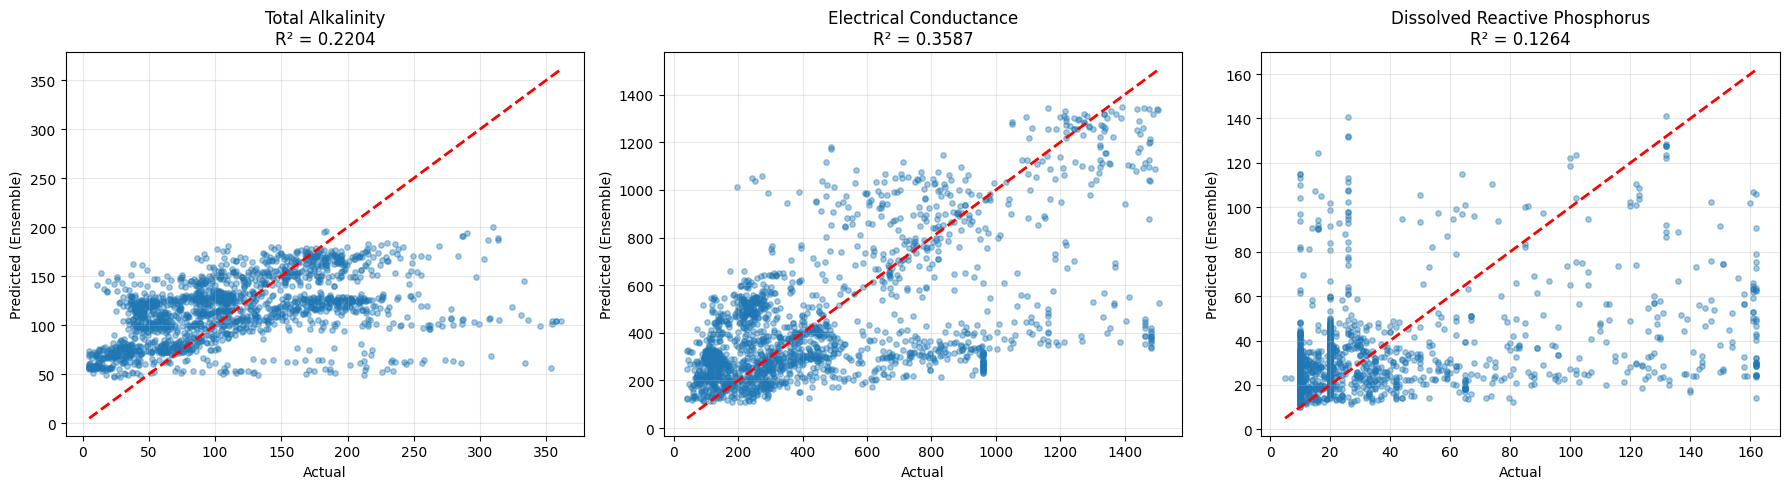


=== Ensemble Hold-out Performance ===
                       Target     R²     RMSE      MAE Weights (L/X)
             Total Alkalinity 0.2204  60.2216  45.7779     0.78/0.22
       Electrical Conductance 0.3587 292.8680 211.1971     1.00/0.00
Dissolved Reactive Phosphorus 0.1264  35.1663  21.6629     1.00/0.00


In [ ]:
results = []
fig, axes = plt.subplots(1, len(TARGET_COLS), figsize=(6 * len(TARGET_COLS), 5))

for i, target in enumerate(TARGET_COLS):
    models    = trained_models[target]
    prep      = models['prep']
    w         = ensemble_weights[target]
    X_ho_proc = prep.transform(X_holdout)
    y_ho      = Y_holdout[target]   # original scale

    # Inverse-transform and blend
    preds  = [inverse_transform(models['lgbm'].predict(X_ho_proc), target),
              inverse_transform(models['xgb'].predict(X_ho_proc),  target)]
    y_pred = sum(w[j] * preds[j] for j in range(len(preds)))

    r2   = r2_score(y_ho, y_pred)
    rmse = np.sqrt(mean_squared_error(y_ho, y_pred))
    mae  = mean_absolute_error(y_ho, y_pred)
    results.append({'Target': target, 'R²': round(r2, 4),
                    'RMSE': round(rmse, 4), 'MAE': round(mae, 4),
                    'Weights (L/X)': f"{w[0]:.2f}/{w[1]:.2f}"})

    ax = axes[i]
    ax.scatter(y_ho, y_pred, alpha=0.4, s=15)
    lims = [min(y_ho.min(), y_pred.min()), max(y_ho.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=2)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted (Ensemble)')
    ax.set_title(f'{target}\nR² = {r2:.4f}')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Ensemble Hold-out Performance ===")
print(pd.DataFrame(results).to_string(index=False))

## 13. SHAP Interpretability

Show **which environmental features drive predictions** using SHAP TreeExplainer on the LightGBM model.  
This is important for judges and for understanding the ecological meaning of the model.


SHAP — Total Alkalinity


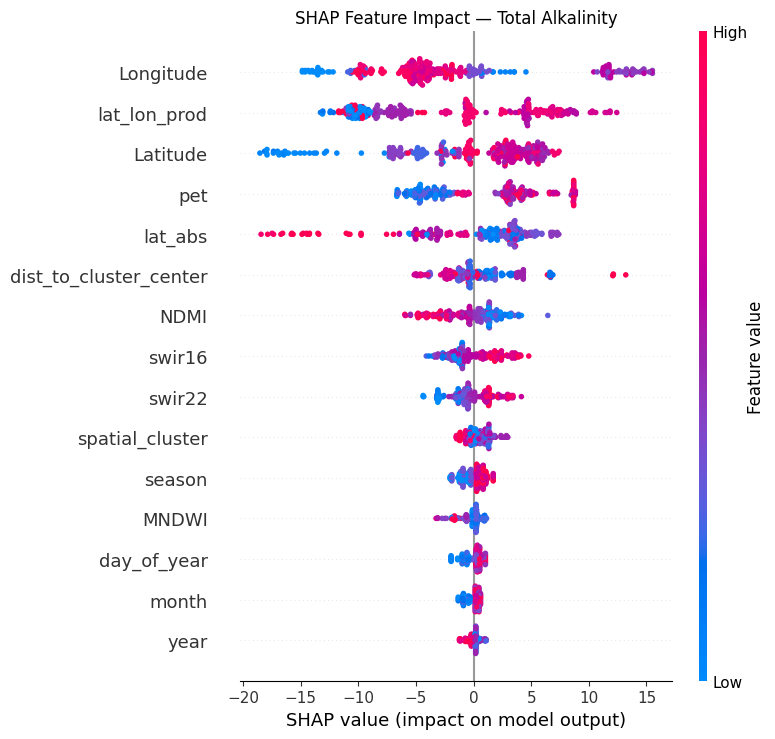

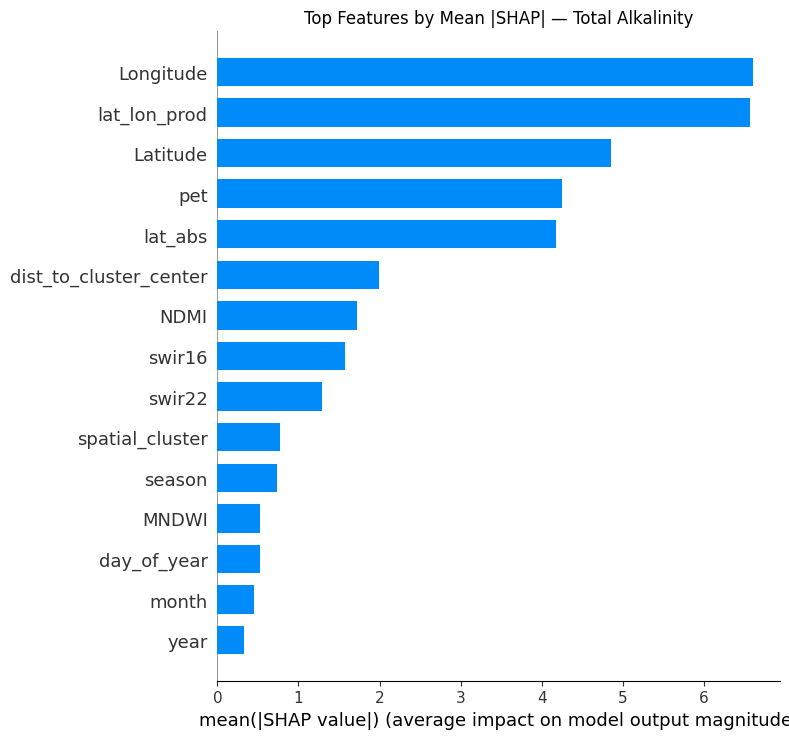


SHAP — Electrical Conductance


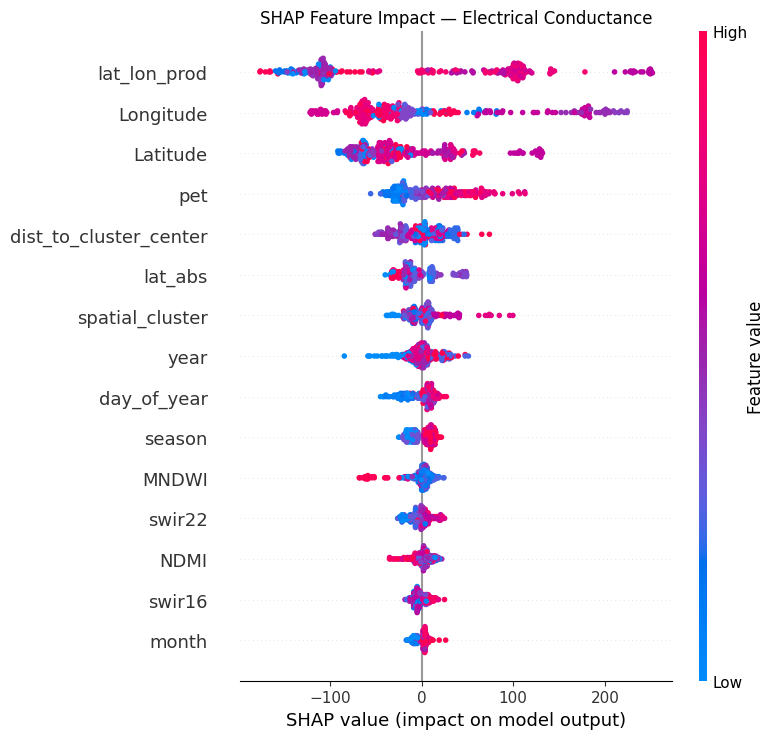

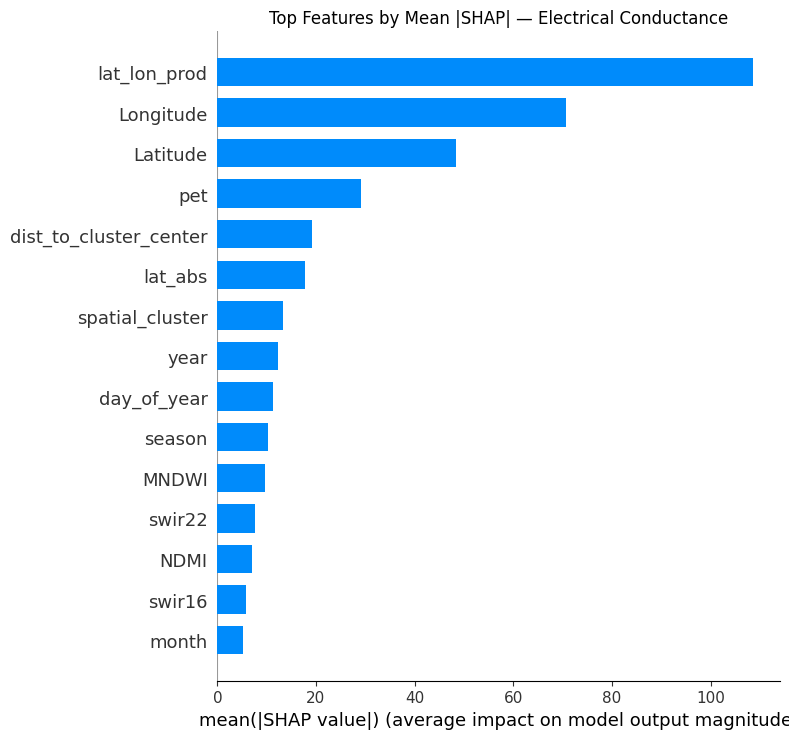


SHAP — Dissolved Reactive Phosphorus


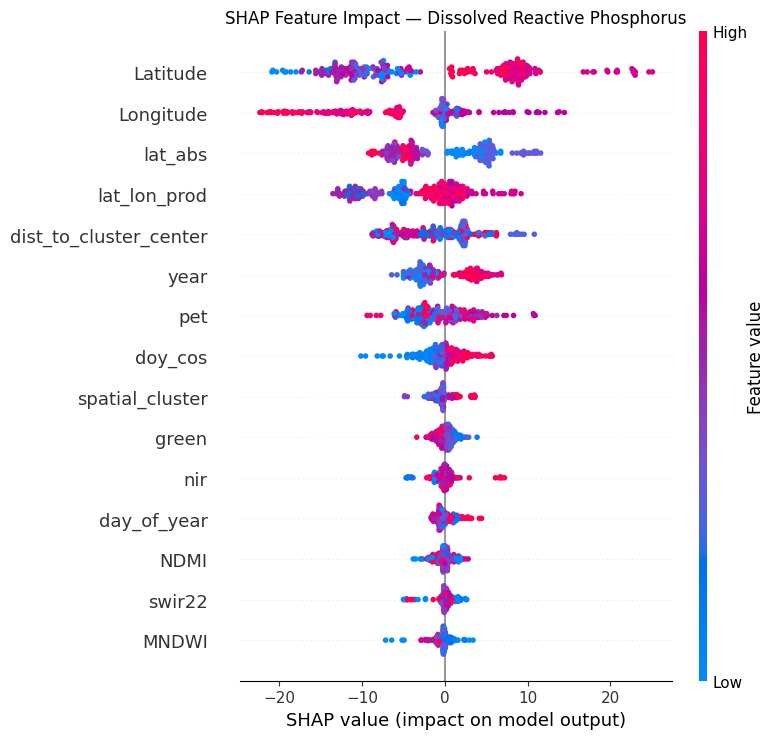

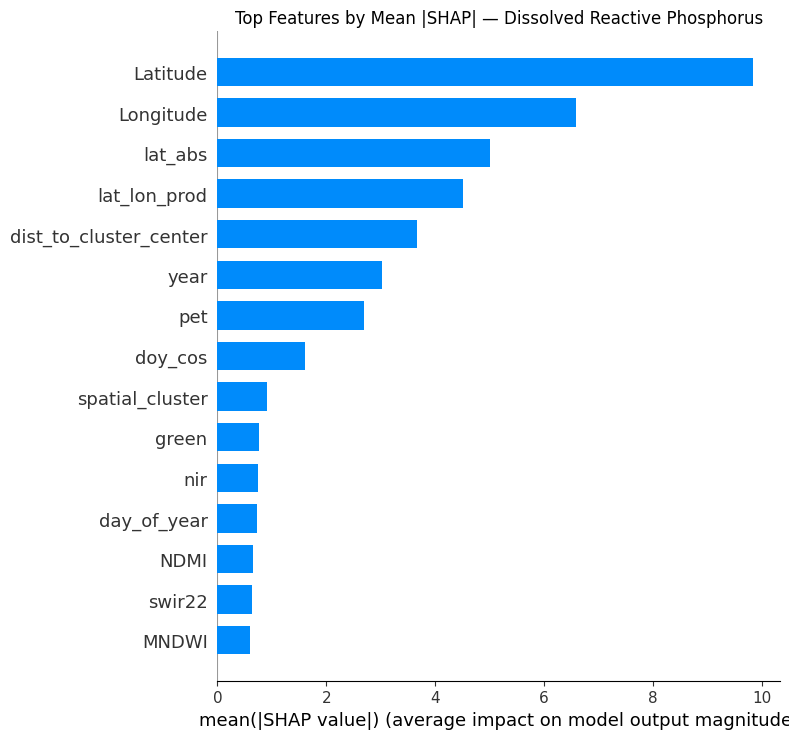

In [ ]:
shap.initjs()

for target in TARGET_COLS:
    print(f"\n{'='*55}")
    print(f"SHAP — {target}")
    print(f"{'='*55}")

    prep  = trained_models[target]['prep']
    model = trained_models[target]['lgbm']

    # Sample 300 hold-out rows for speed
    sample_idx = np.random.choice(len(X_holdout), size=min(300, len(X_holdout)), replace=False)
    X_sample   = prep.transform(X_holdout.iloc[sample_idx])

    # Reconstruct feature names after ColumnTransformer
    num_names = numeric_features
    if categorical_features:
        cat_names = list(
            prep.named_transformers_['cat']
            .named_steps['encoder']
            .get_feature_names_out(categorical_features)
        )
    else:
        cat_names = []
    feat_names = num_names + cat_names

    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)

    # Beeswarm summary plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_sample, feature_names=feat_names,
                      max_display=15, show=False)
    plt.title(f'SHAP Feature Impact — {target}', fontsize=12)
    plt.tight_layout()
    plt.show()

    # Bar chart: mean |SHAP|
    plt.figure(figsize=(10, 5))
    shap.summary_plot(shap_values, X_sample, feature_names=feat_names,
                      plot_type='bar', max_display=15, show=False)
    plt.title(f'Top Features by Mean |SHAP| — {target}', fontsize=12)
    plt.tight_layout()
    plt.show()

## 13. Generate Submission File

Retrain each model on **100% of the training data** and predict with the optimised ensemble weights.

In [ ]:
X_val      = df_val.drop(columns=TARGET_COLS + ['Sample Date'], errors='ignore')
submission = df_submission.copy()

for target in TARGET_COLS:
    print(f"Predicting: {target}  {'[log1p → expm1]' if log_targets[target] else '[linear]'}")
    w = ensemble_weights[target]

    # Retrain on ALL training data with transformed targets
    full_prep  = copy.deepcopy(preprocessor)
    X_all_proc = full_prep.fit_transform(X)
    X_val_proc = full_prep.transform(X_val)

    lgbm_f = copy.deepcopy(trained_models[target]['lgbm'])
    xgb_f  = copy.deepcopy(trained_models[target]['xgb'])

    lgbm_f.fit(X_all_proc, Y_t[target])   # train on log-transformed targets
    xgb_f.fit(X_all_proc,  Y_t[target])

    # Ensemble prediction + inverse transform back to original scale
    submission[target] = (
        w[0] * inverse_transform(lgbm_f.predict(X_val_proc), target) +
        w[1] * inverse_transform(xgb_f.predict(X_val_proc),  target)
    )
    print(f"  mean={submission[target].mean():.3f}  std={submission[target].std():.3f}")

submission.to_csv('submission_final.csv', index=False)
print("\nsubmission_final.csv saved.")
print(submission[TARGET_COLS].describe().round(3))

Predicting: Total Alkalinity
  mean=128.979  std=25.857
Predicting: Electrical Conductance
  mean=386.981  std=128.866
Predicting: Dissolved Reactive Phosphorus
  mean=32.757  std=11.535

submission_final.csv saved.
       Total Alkalinity  Electrical Conductance  Dissolved Reactive Phosphorus
count           200.000                 200.000                        200.000
mean            128.979                 386.981                         32.757
std              25.857                 128.866                         11.535
min              70.952                  82.258                         11.424
25%             112.742                 291.270                         23.279
50%             125.236                 372.241                         31.522
75%             145.113                 484.236                         39.814
max             205.146                 739.178                         63.303
